# Training the stream-cleaning U-Net, step by step

This notebook builds on `create_data.ipynb`: it reuses the same background +
matched-filter + `StreamInjector` construction, then wires up the rest of the
pipeline -- `StreamMapDataset`, `StreamMapTransform`/`RobustNormalizer`,
`models.unet.UNet`, `models.losses`, `training.plain_runner.PlainTrainer`, and
`evaluation/` -- and runs one short **real** training loop end to end.

This is a smoke-scale run (few epochs, few steps per epoch, small images) --
it proves the whole pipeline trains and evaluates for real, not a
scientifically tuned model. Scaling up (more steps/epochs, GPU, the
`training/hyrax_runner.py` orchestration layer) is future work.


In [1]:
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

from streamgoggles.background import Background
from streamgoggles.background_sources import StreamObsLightBackgroundSource, StudyRegion
from streamgoggles.config import DistributionType, ParameterSpec, StreamConfig
from streamgoggles.data_preparation import Cut
from streamgoggles.datasets.stream_map_dataset import StreamMapDataset, stream_map_collate_fn
from streamgoggles.datasets.transforms import RobustNormalizer, StreamMapTransform
from streamgoggles.evaluation.baseline_threshold import build_baseline
from streamgoggles.evaluation.completeness_purity import evaluate_on_grid, plot_recovery_vs_parameter
from streamgoggles.evaluation.metrics import dice, iou
from streamgoggles.injector import StreamInjector
from streamgoggles.matched_filter import PixelizationSpec, ShiftedColorBoxFilter, StreamobsSplineFilter
from streamgoggles.models.losses import get_loss
from streamgoggles.models.unet import UNet
from streamgoggles.storage import BackgroundMapStore, ModelStore, SimulationStore
from streamgoggles.stream_sources import StreamObsSource
from streamgoggles.training.plain_runner import PlainTrainer

%matplotlib inline


## 1. Configuration

Background/matched-filter/window config mirrors `create_data.ipynb` (smaller
`image_size_pix` here, for speed -- many samples get generated on the fly
during training, unlike that notebook's single hand-built sample).

`stream_param_cfg` is new: it becomes a `StreamConfig`, whose `richness` is
**DISCRETE over 3 values** rather than fixed -- giving the training set some
real diversity, and giving the eval grid (built automatically from every
DISCRETE/UNIFORM parameter, one point per combination) 3 points to later plot
recovery-vs-richness over (§7).


In [2]:
SEED = 42

study_region_cfg = dict(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

cuts_cfg = [
    dict(quantity="mag", band="g", op="<", value=26.5),
    dict(quantity="mag", band="r", op="<", value=26.0),
]
clipping_cfg = {"g": {"min": 16.0, "max": 26.5}, "r": {"min": 16.0, "max": 26.0}}

background_cfg = dict(
    source="light",
    survey="lsst",
    release="yr1",
    source_kwargs={},
    finalize={"enabled": False},
)

filters_cfg = dict(
    good=dict(type="isochrone", reference_isochrone=dict(age=12.5, z=0.0002)),
    decoy=dict(type="shifted_box", reference="good", color_shift=0.5, color_width=0.3),
)

matched_filter_cfg = dict(
    bands=["g", "r"],
    pixelization=dict(nside=64, image_size_pix=(20, 20), pixel_scale_deg=1.0),
    distance_moduli=[16.0, 16.8],
)

window_cfg = dict(min_stream_length_deg=5.0, max_attempts=100)

# Free parameter (richness) + fixed morphology/geometry -- same shape
# StreamInjector.inject_single_stream expects (decision: richness_kind="nstars").
stream_param_cfg = dict(
    morphology="uniform",
    richness=[1500, 2500, 4000],  # DISCRETE nstars
    width=0.2,
    length=8.0,
    distance_modulus=16.8,  # matches a trial distance in matched_filter_cfg
    age=12.5,
    z=0.0002,
)

model_cfg = dict(base_width=8, depth=2, head="softplus")

train_cfg = dict(
    epochs=4,
    steps_per_epoch=16,
    batch_size=4,
    lr=1e-3,
    background_fraction=0.2,
    loss_name="weighted_mse",
)

namespace = f"{background_cfg['survey']}_{background_cfg['release']}"


## 2. Build background + matched filters + injector

Exactly `create_data.ipynb` §2.2-2.3 and §3 -- see that notebook for the
step-by-step breakdown of what `StreamInjector.inject_single_stream` does
internally.


In [3]:
study_region = StudyRegion(**study_region_cfg)
pix = PixelizationSpec(**matched_filter_cfg["pixelization"])

matched_filters = {}
for name, cfg in filters_cfg.items():
    if cfg["type"] == "isochrone":
        matched_filters[name] = StreamobsSplineFilter(
            iso_config=cfg["reference_isochrone"], namespace=namespace
        )
    elif cfg["type"] == "shifted_box":
        matched_filters[name] = ShiftedColorBoxFilter(
            reference_filter=matched_filters[cfg["reference"]],
            color_shift=cfg["color_shift"],
            color_width=cfg["color_width"],
        )
    else:
        raise ValueError(f"unknown filter type {cfg['type']!r}")

cuts = [Cut(**c) for c in cuts_cfg]
bg_store = BackgroundMapStore(tempfile.mkdtemp(prefix="streamgoggles_train_bgmaps_"))

background = Background.load_or_cache(
    source=StreamObsLightBackgroundSource(),
    source_cfg=background_cfg["source_kwargs"],
    study_region=study_region,
    cuts=cuts,
    clipping=clipping_cfg,
    matched_filters=matched_filters,
    bands=matched_filter_cfg["bands"],
    distance_moduli=matched_filter_cfg["distance_moduli"],
    finalize_cfg=background_cfg["finalize"],
    store=bg_store,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    filter_configs=filters_cfg,
)

n_channels = len(matched_filter_cfg["distance_moduli"]) * len(matched_filters)
print(f"background catalog: {len(background.catalog)} stars (after cuts+clipping)")
print(f"n_channels = n_distances * n_filters = {n_channels}")


Loading survey data for 'lsst_yr1'...
  Loading config from: lsst_yr1.yaml

LOADING SURVEY DATA FILES
Survey data directory: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/surveys/lsst_yr1

Fallback directory for shared data files: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/others

Available bands: g, i, r, u, y, z


Loading survey properties...
Loading magnitude limit maps...
  ✓ Success for g-band magnitude limit
  ⚠ Warning: 'maglim_map_i' not specified in config (skipping i-band)
  ✓ Success for r-band magnitude limit
  ⚠ Warning: 'maglim_map_u' not specified in config (skipping u-band)
  ⚠ Warning: 'maglim_map_y' not specified in config (skipping y-band)
  ⚠ Warning: 'maglim_map_z' not specified in config (skipping z-band)

Loading completeness/efficiency function...
  Loading Completeness/efficiency function...
    File: lsst_dc2_stellar_efficiency_cutr.csv
    ✓ Success
  Loading Detection efficiency function...
    File: lsst_dc

/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/background/background.py:159: UserWarning: Requested nside=4096 exceeds the magnitude-limit map resolution (nside=128). Capping to nside=128.
  return gen.generate(


background catalog: 6397827 stars (after cuts+clipping)
n_channels = n_distances * n_filters = 4


In [4]:
injector = StreamInjector(
    background=background,
    matched_filters=matched_filters,
    stream_source=StreamObsSource(),
    cuts=cuts,
    clipping=clipping_cfg,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    bands=tuple(matched_filter_cfg["bands"]),
    richness_kind="nstars",
    finalize_cfg=background_cfg["finalize"],
)
injector


✓ Using cached survey data for 'lsst_yr1'


## 3. `StreamConfig` and the training/eval datasets

`StreamMapDataset` in training mode (`eval_mode=False`) generates a fresh
sample on every `__getitem__` call -- a mix of real injected streams and
(with probability `background_fraction`) pure-background windows. In eval
mode it walks a fixed, persisted grid: since `richness` is the only DISCRETE
parameter here, that grid has exactly `len(stream_param_cfg["richness"])`
points, one per richness value.


In [5]:
params = {
    "morphology": ParameterSpec(
        name="morphology", dist_type=DistributionType.FIXED, value=stream_param_cfg["morphology"]
    ),
    "richness": ParameterSpec(
        name="richness", dist_type=DistributionType.DISCRETE, values=stream_param_cfg["richness"]
    ),
    "width": ParameterSpec(name="width", dist_type=DistributionType.FIXED, value=stream_param_cfg["width"]),
    "length": ParameterSpec(name="length", dist_type=DistributionType.FIXED, value=stream_param_cfg["length"]),
    "distance_modulus": ParameterSpec(
        name="distance_modulus", dist_type=DistributionType.FIXED, value=stream_param_cfg["distance_modulus"]
    ),
    "age": ParameterSpec(name="age", dist_type=DistributionType.FIXED, value=stream_param_cfg["age"]),
    "z": ParameterSpec(name="z", dist_type=DistributionType.FIXED, value=stream_param_cfg["z"]),
}
stream_config = StreamConfig(
    params=params,
    background_fraction=train_cfg["background_fraction"],
    persist=False,
    richness_kind="nstars",
)

sim_store = SimulationStore(tempfile.mkdtemp(prefix="streamgoggles_train_sims_"))

train_dataset = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    store=sim_store,
    eval_mode=False,
    steps_per_epoch=train_cfg["steps_per_epoch"],
    rng=np.random.default_rng(SEED),
)
eval_dataset = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    store=sim_store,
    eval_mode=True,
)
print(f"train_dataset: {len(train_dataset)} samples/epoch (on the fly)")
print(f"eval_dataset: {len(eval_dataset)} samples (fixed grid, one per richness value)")


train_dataset: 16 samples/epoch (on the fly)
eval_dataset: 3 samples (fixed grid, one per richness value)


### 3.1 Fit a normalizer, wrap both datasets with `StreamMapTransform`

`RobustNormalizer.fit()` wants pooled statistics; a handful of pre-drawn
training samples, concatenated along the spatial axis, is enough for this
smoke-scale run. Only `map_stack` (the input) gets normalized -- `label_stack`
stays in raw star-count units throughout, matching `models.losses`'
`label_policy="stream_count"` convention. Training gets `augment=True`
(flips/90-degree rotations); eval stays `augment=False` for reproducibility.


In [6]:
class _TransformedDataset:
    """Thin wrapper applying a transform to every item; forwards any other
    attribute access (e.g. eval_mode) to the wrapped dataset unchanged."""

    def __init__(self, base, transform):
        self.base = base
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        return self.transform(self.base[idx])

    def __getattr__(self, name):
        return getattr(self.base, name)


fit_samples = [train_dataset[i] for i in range(8)]
pooled_map_stack = np.concatenate([s["map_stack"] for s in fit_samples], axis=1)
pooled_valid_mask = np.concatenate([s["valid_mask"] for s in fit_samples], axis=0)

normalizer = RobustNormalizer()
normalizer.fit(pooled_map_stack, pooled_valid_mask)
print(f"per-channel mean: {normalizer.mean}")
print(f"per-channel std:  {normalizer.std}")

train_transform = StreamMapTransform(normalizer=normalizer, augment=True, rng=np.random.default_rng(SEED + 1))
eval_transform = StreamMapTransform(normalizer=normalizer, augment=False)

train_dataset_norm = _TransformedDataset(train_dataset, train_transform)
eval_dataset_norm = _TransformedDataset(eval_dataset, eval_transform)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

per-channel mean: [1095.03430176  771.83148193 1217.51904297  778.12628174]
per-channel std:  [263.54714966 201.76725769 309.12463379 211.31636047]


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 4. Model, loss, optimizer, trainer

`in_channels`/`out_channels` = `n_channels` (§2): one channel per
`(filter, distance)` pair. `head="softplus"` keeps the prediction
non-negative, matching `label_policy="stream_count"`'s literal star-count
target; `loss_name="weighted_mse"` weights each pixel's squared error by its
own target count, emphasizing the (rare) high-count stream pixels over the
much more common near-zero background pixels.


In [7]:
torch.manual_seed(SEED)
model = UNet(in_channels=n_channels, out_channels=n_channels, **model_cfg)
optimizer = torch.optim.Adam(model.parameters(), lr=train_cfg["lr"])
loss_fn = get_loss(train_cfg["loss_name"])
trainer = PlainTrainer(model=model, optimizer=optimizer, loss_fn=loss_fn, device="cpu")
sum(p.numel() for p in model.parameters())


30180

## 5. Train

In [8]:
train_dl = DataLoader(
    train_dataset_norm, batch_size=train_cfg["batch_size"], collate_fn=stream_map_collate_fn
)
val_dl = DataLoader(
    eval_dataset_norm, batch_size=train_cfg["batch_size"], collate_fn=stream_map_collate_fn
)

model_store = ModelStore(tempfile.mkdtemp(prefix="streamgoggles_train_models_"))
model_config = dict(in_channels=n_channels, out_channels=n_channels, **model_cfg)
run_config = {"model_config": model_config, "loss_name": train_cfg["loss_name"], "seed": SEED}

result = trainer.train(
    train_dl,
    val_dl=val_dl,
    epochs=train_cfg["epochs"],
    model_store=model_store,
    config=run_config,
    save_every=train_cfg["epochs"],
)
print(f"epochs_run={result['epochs_run']}")
print(f"train_losses={result['train_losses']}")
print(f"val_losses={result['val_losses']}")
print(f"final_checkpoint_path={result['final_checkpoint_path']}")


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

...

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

epochs_run=4
train_losses=[148.32959365844727, 181.28167152404785, 137.06300163269043, 129.82054138183594]
val_losses=[147.67237854003906, 147.4277801513672, 147.79205322265625, 148.9697723388672]
final_checkpoint_path=/var/folders/9j/zk4h50g505d635j69p9tgwbc0000gp/T/streamgoggles_train_models_5vpawrwp/c8b6/327ac0b4b95dfcc996bb452a66b4e2d9399a


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


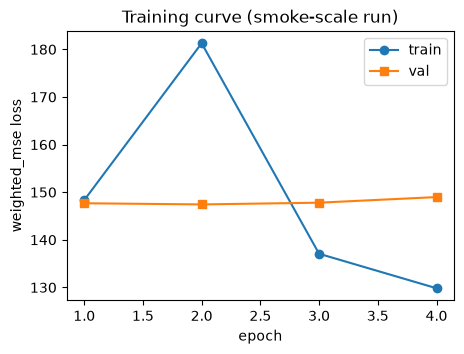

In [9]:
fig, ax = plt.subplots(figsize=(5, 3.5))
epochs_axis = np.arange(1, train_cfg["epochs"] + 1)
ax.plot(epochs_axis, result["train_losses"], marker="o", label="train")
ax.plot(epochs_axis, result["val_losses"], marker="s", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel(f"{train_cfg['loss_name']} loss")
ax.set_title("Training curve (smoke-scale run)")
ax.legend()
plt.show()


## 6. Inspect one prediction

The `"good"` filter's channel at the stream's own true `distance_modulus` --
the channel a real detection should show up most clearly in.


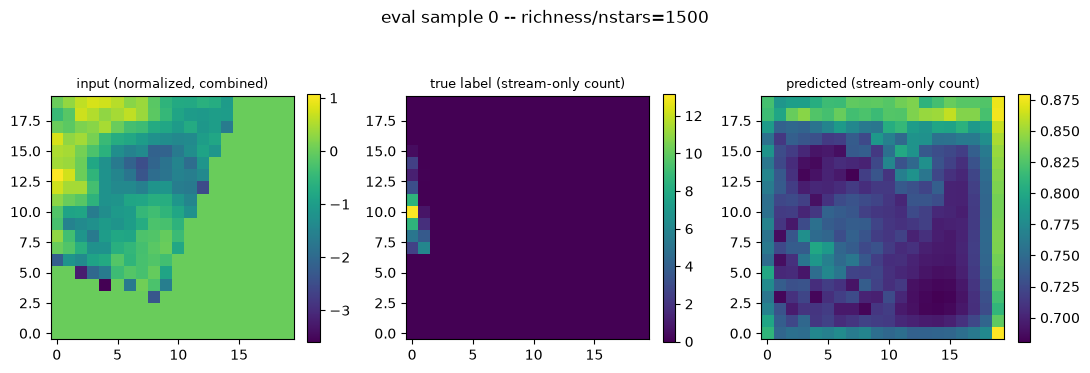

In [10]:
sample0 = eval_dataset_norm[0]
channels_meta = sample0["metadata"]["channels"]
good_idx = next(
    i
    for i, ch in enumerate(channels_meta)
    if ch["filter"] == "good" and ch["distance_modulus"] == stream_param_cfg["distance_modulus"]
)

model.eval()
with torch.no_grad():
    x = torch.from_numpy(sample0["map_stack"]).unsqueeze(0)
    pred0 = model(x)[0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, img, title in zip(
    axes,
    [sample0["map_stack"][good_idx], sample0["label_stack"][good_idx], pred0[good_idx]],
    ["input (normalized, combined)", "true label (stream-only count)", "predicted (stream-only count)"],
):
    im = ax.imshow(img, origin="lower", cmap="viridis")
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"eval sample 0 -- richness/nstars={sample0['params']['nstars']}")
plt.tight_layout()
plt.show()


## 7. Evaluate on the grid, compare to the k·σ baseline

`evaluate_on_grid` walks every point of `eval_dataset_norm` (one per
richness value) and computes each requested metric per sample.
`baseline_threshold.build_baseline` is a trivial, non-learned comparison
(mean + k·σ on the same `"good"` channel of the *unnormalized* combined
map, since a threshold in raw count units is what that function expects) --
the network should beat it if it has learned something.


In [11]:
results = evaluate_on_grid(model, eval_dataset_norm, metrics=["mse", "dice", "correlation", "weighted_recall"])

baseline_dice = []
for idx in results["id"]:
    raw_sample = eval_dataset[idx]  # unnormalized -- real count units
    baseline_pred = build_baseline(raw_sample["map_stack"][good_idx], raw_sample["valid_mask"], k=2.0)
    baseline_dice.append(dice(baseline_pred, raw_sample["label_stack"][good_idx], raw_sample["valid_mask"]))
results["baseline_dice"] = baseline_dice

results


,age,band_1,band_2,distance_modulus,length,morphology,nstars,width,z,id,mse,dice,correlation,weighted_recall,baseline_dice
0,12.5,g,r,16.8,8.0,uniform,1500,0.2,0.0002,0,1.120862,0.089109,-0.020339,1.0,0.153846
1,12.5,g,r,16.8,8.0,uniform,2500,0.2,0.0002,1,2.713113,0.124853,-0.064817,1.0,0.000000
2,12.5,g,r,16.8,8.0,uniform,4000,0.2,0.0002,2,4.260613,0.121581,-0.032740,1.0,0.000000


mean network dice:  0.112
mean baseline dice: 0.051


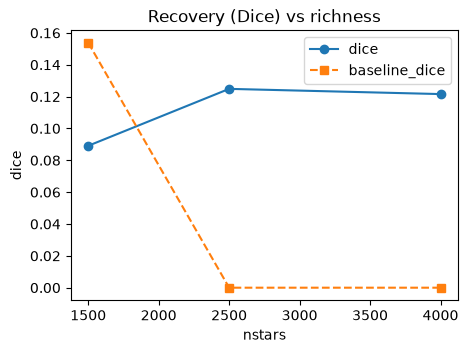

In [12]:
print(f"mean network dice:  {results['dice'].mean():.3f}")
print(f"mean baseline dice: {results['baseline_dice'].mean():.3f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
plot_recovery_vs_parameter(results, param_name="nstars", metric="dice", ax=ax, baseline_metric="baseline_dice")
ax.set_title("Recovery (Dice) vs richness")
plt.show()


## Summary

| Piece | Module |
|---|---|
| Background + matched filters + injector | `background.py`, `matched_filter.py`, `injector.py` (same as `create_data.ipynb`) |
| On-the-fly training samples + fixed eval grid | `datasets/stream_map_dataset.py` |
| Normalization + augmentation | `datasets/transforms.py` |
| Model | `models/unet.py` |
| Loss (`weighted_mse`, primary for `label_policy="stream_count"`) | `models/losses.py` |
| Training loop + checkpointing | `training/plain_runner.py` |
| Metrics, trivial baseline, per-parameter recovery curve | `evaluation/` |

This was a **smoke-scale** run (small images, few epochs/steps, no GPU) to
prove every piece of the pipeline wires together and trains for real --
not a tuned model. Next steps for a real training run: bigger
`image_size_pix`/`steps_per_epoch`/`epochs`, a GPU device, and eventually
`training/hyrax_runner.py` for orchestrated/distributed training (still a
stub as of this notebook).
